Model Accuracy: 0.987037037037037


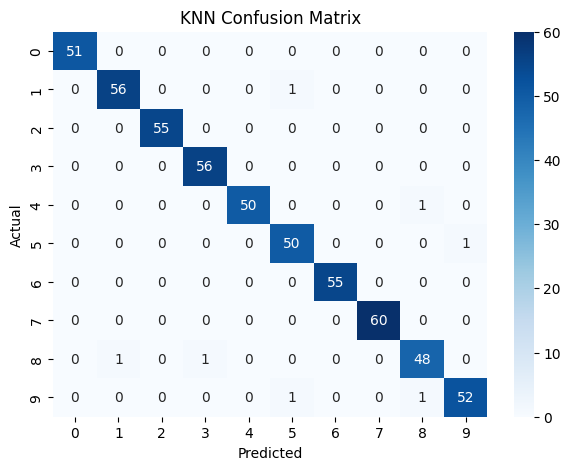


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       0.98      0.98      0.98        57
           2       1.00      1.00      1.00        55
           3       0.98      1.00      0.99        56
           4       1.00      0.98      0.99        51
           5       0.96      0.98      0.97        51
           6       1.00      1.00      1.00        55
           7       1.00      1.00      1.00        60
           8       0.96      0.96      0.96        50
           9       0.98      0.96      0.97        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540



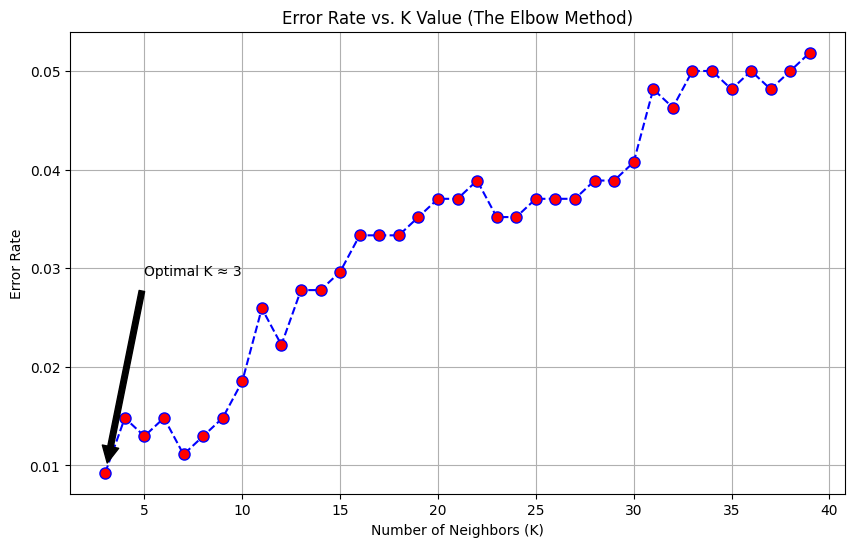

In [2]:
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np

# Load dataset
digits = load_digits()

# Create DataFrame
df = pd.DataFrame(digits.data, digits.target)
df['target'] = digits.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis='columns'),
    df.target,
    test_size=0.3,
    random_state=10
)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Model accuracy
print("Model Accuracy:", knn.score(X_test, y_test))

# Predictions and Confusion Matrix
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(7, 5))
sn.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

k_range = range(3, 40)
error_rate=[]

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    # Average of where predictions don't match the actual test labels
    error_rate.append(np.mean(pred_i != y_test))

# --- 2. Plotting the Elbow Curve ---
plt.figure(figsize=(10, 6))
plt.plot(k_range, error_rate, color='blue', linestyle='dashed', 
         marker='o', markerfacecolor='red', markersize=8)

plt.title('Error Rate vs. K Value (The Elbow Method)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Error Rate')

# Annotating the 'Elbow' (Optional)
# This finds the K with the minimum error to help you spot it
min_error_k = k_range[np.argmin(error_rate)]
plt.annotate(f'Optimal K ≈ {min_error_k}', 
             xy=(min_error_k, min(error_rate)), 
             xytext=(min_error_k+2, min(error_rate)+0.02),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.grid(True)
plt.show()